# Task 2

### Importing libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional
from torch.utils.data import DataLoader, TensorDataset
from transformers import ViTForImageClassification, ViTImageProcessor
from datasets import load_dataset
from PIL import Image
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import random
import numpy as np

from huggingface_hub import notebook_login

if torch.cuda.is_available() == True:
    device = 'cuda'
else:
    device = 'cpu'

print(f'device: {device}')


device: cuda


# Task 2.1

### Loading models and data

In [ ]:
model_name = 'google/vit-base-patch16-224'

image_transformer = ViTForImageClassification.from_pretrained(model_name)
image_processor = ViTImageProcessor.from_pretrained(model_name)

image1 = Image.open('../data/image_1.jpg')
image2 = Image.open('../data/image_2.jpg')
image3 = Image.open('../data/image_3.jpg')


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

### Recording class labels using ViT

In [ ]:
transformer_input = image_processor(images=[image1, image2, image3], return_tensors='pt')

output = image_transformer(**transformer_input)
predictions = output.logits.argmax(dim=1)

for prediction in predictions:
    print(image_transformer.config.id2label[prediction.item()])



jay
ballpoint, ballpoint pen, ballpen, Biro
tabby, tabby cat


# Task 2.2 + 2.3

### Loading models and data

In [ ]:
model_name = 'google/vit-base-patch16-224'

image_transformer = ViTForImageClassification.from_pretrained(model_name, attn_implementation='eager')
image_processor = ViTImageProcessor.from_pretrained(model_name)

image = Image.open('../data/image_2.jpg')


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

### Visualizing patch attention using attention map

final layer attention matrix: torch.Size([1, 12, 197, 197])
averaged out final layer attention matrix: torch.Size([1, 197, 197])
[CLS] token vector:  torch.Size([1, 197])
reshaped [CLS] vector: torch.Size([1, 14, 14])


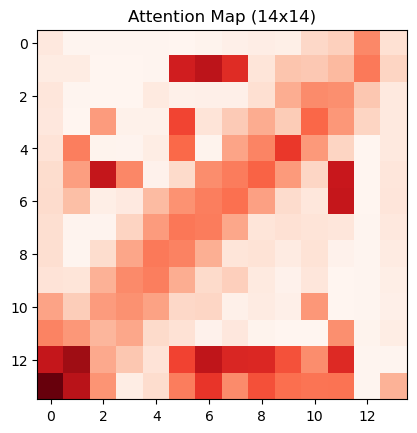

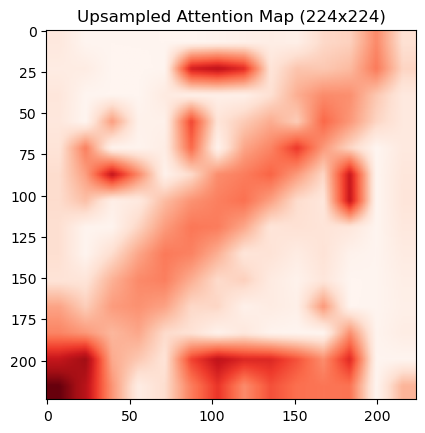

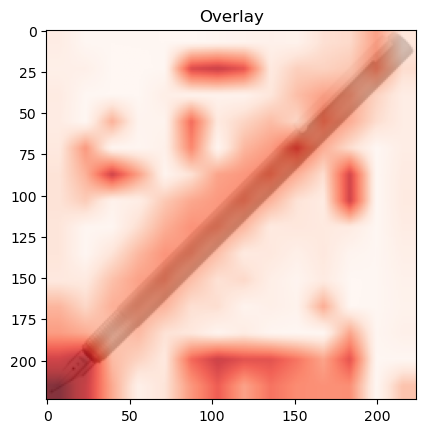

In [ ]:
transformer_input = image_processor(images=image, return_tensors='pt')

transformer_output = image_transformer(**transformer_input, output_attentions=True)

final_layer_attention = transformer_output.attentions[-1]
print(f'final layer attention matrix: {final_layer_attention.shape}')

averaged_final_layer_attention = final_layer_attention.mean(dim=1)
print(f'averaged out final layer attention matrix: {averaged_final_layer_attention.shape}')

cls_token_vector = averaged_final_layer_attention[:, 0, :]
print(f'[CLS] token vector:  {cls_token_vector.shape}')

cls_token_vector = cls_token_vector[:, 1:]
reshaped_vector = cls_token_vector.reshape(1, 14, 14)

print(f'reshaped [CLS] vector: {reshaped_vector.shape}')

attention_map = reshaped_vector

upsample_input = attention_map.unsqueeze(1)
upsampled_attention_map = functional.interpolate(upsample_input, size=(224,224), mode='bilinear', align_corners=False)

attention_map = attention_map.detach().squeeze().cpu().numpy()
upsampled_attention_map = upsampled_attention_map.detach().squeeze().cpu().numpy()

plt.figure()
plt.imshow(attention_map, cmap='Reds')
plt.title('Attention Map (14x14)')

plt.figure()
plt.imshow(upsampled_attention_map, cmap='Reds')
plt.title('Upsampled Attention Map (224x224)')
plt.show()

plt.figure()
plt.imshow(image.resize((224,224)))
plt.imshow(upsampled_attention_map, alpha=0.8, cmap='Reds')
plt.title('Overlay')
plt.show()



# Task 2.4

### Loading models and data

In [2]:
model_name = 'google/vit-base-patch16-224'

image_transformer = ViTForImageClassification.from_pretrained(model_name)
image_processor = ViTImageProcessor.from_pretrained(model_name)

notebook_login()
imagenet_dataset = load_dataset("ILSVRC/imagenet-1k", split="validation", streaming=True).take(64)


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

### Evaluating masking

In [4]:
images = []
labels = []

for row in imagenet_dataset:
    images.append(row['image'])
    labels.append(row['label'])

processed_image = image_processor(images=images, return_tensors='pt')
concat_labels = torch.tensor(labels)

no_mask = processed_image['pixel_values']
random_mask = no_mask.clone()
structured_mask = no_mask.clone()

percents = [0.25, 0.5, 0.75]
no_mask_accuracy = []
random_mask_accuracy = []
structued_mask_accuracy = []

for percent in percents:
    mask_amount = int(percent * 196)
    random_row_col_pairs = {}

    for i in range(mask_amount):
        for j in range(random_mask.shape[0]):
            patch_row = random.randint(0,13)
            patch_col = random.randint(0,13)

            if j not in random_row_col_pairs.keys():
                random_row_col_pairs[j] = []

            if (patch_row, patch_col) in random_row_col_pairs[j]:
                while (patch_row, patch_col) in random_row_col_pairs[j]:
                    patch_row = random.randint(0,13)
                    patch_col = random.randint(0,13)

            random_row_col_pairs[j].append((patch_row, patch_col))

            random_mask[j, :, patch_row*16:patch_row*16 + 16, patch_col*16:patch_col*16 + 16] = 0

    length_masked_area = np.sqrt(mask_amount)
    length_from_center = length_masked_area/2

    structured_mask[:, :, int(16 * (6.5-length_from_center)): int(16 *(6.5+length_from_center)), int(16 * (6.5-length_from_center)): int(16 *(6.5+length_from_center))] = 0

    no_mask_predictions = image_transformer(no_mask).logits.argmax(dim=1)
    random_mask_predictions = image_transformer(random_mask).logits.argmax(dim=1)
    structured_mask_predictions = image_transformer(structured_mask).logits.argmax(dim=1)

    curr_no_mask_accuracy = accuracy_score(concat_labels.detach().cpu().numpy(), no_mask_predictions.detach().cpu().numpy())
    curr_random_mask_accuracy = accuracy_score(concat_labels.detach().cpu().numpy(), random_mask_predictions.detach().cpu().numpy())
    curr_structured_mask_accuracy = accuracy_score(concat_labels.detach().cpu().numpy(), structured_mask_predictions.detach().cpu().numpy())

    no_mask_accuracy.append(curr_no_mask_accuracy)
    random_mask_accuracy.append(curr_random_mask_accuracy)
    structued_mask_accuracy.append(curr_structured_mask_accuracy)

    print(f'accuracy for {percent*100}% no mask: {curr_no_mask_accuracy}')
    print(f'accuracy for {percent*100}% random mask: {curr_random_mask_accuracy}')
    print(f'accuracy for {percent*100}% structured mask: {curr_structured_mask_accuracy}')

    random_mask = no_mask.clone()
    structured_mask = no_mask.clone()




accuracy for 25.0% no mask: 0.84375
accuracy for 25.0% random mask: 0.796875
accuracy for 25.0% structured mask: 0.671875
accuracy for 50.0% no mask: 0.84375
accuracy for 50.0% random mask: 0.6875
accuracy for 50.0% structured mask: 0.359375
accuracy for 75.0% no mask: 0.84375
accuracy for 75.0% random mask: 0.3125
accuracy for 75.0% structured mask: 0.171875


### Plotting accuracy for no mask, random mask, and structured mask

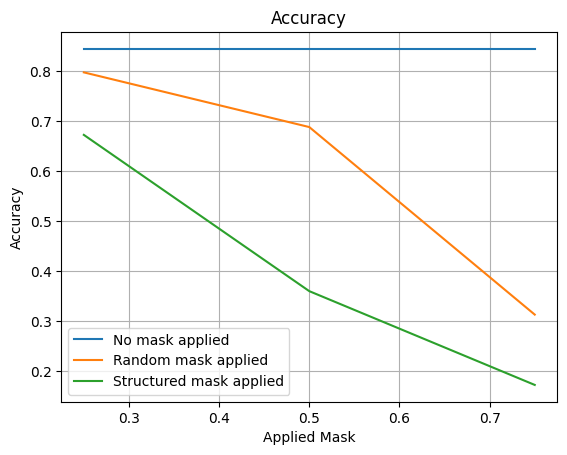

In [7]:
plt.figure()
plt.plot(percents, no_mask_accuracy, label='No mask applied')
plt.plot(percents, random_mask_accuracy, label='Random mask applied')
plt.plot(percents, structued_mask_accuracy, label='Structured mask applied')
plt.title('Accuracy')
plt.xlabel('Applied Mask')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()


# Task 2.5

### Loading models and data

In [3]:
model_name = 'google/vit-base-patch16-224'

image_transformer = ViTForImageClassification.from_pretrained(model_name)
image_processor = ViTImageProcessor.from_pretrained(model_name)

image_transformer = image_transformer.to(device)

notebook_login()
imagenet_train = load_dataset("ILSVRC/imagenet-1k", split="train", streaming=True).take(20000)
imagenet_validation = load_dataset("ILSVRC/imagenet-1k", split="validation", streaming=True).take(5000)


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

### 1) Training using [CLS] token

In [4]:
training_attention_output = []
validation_attention_output = []

def cls_training_hook(module, input, output):
    training_attention_output.append(output[:, 0, :].detach().cpu())


def cls_validation_hook(module, input, output):
    validation_attention_output.append(output[:, 0, :].detach().cpu())


def batch_helper(batch):
    images = []
    labels = []

    for row in batch:
        images.append(row['image'].convert('RGB'))
        labels.append(row['label'])

    processed_images = image_processor(images=images, return_tensors='pt')
    processed_labels = torch.tensor(labels)

    return processed_images['pixel_values'], processed_labels


EPOCHS = 10

training_labels = []
validation_labels = []

training_data = DataLoader(imagenet_train, batch_size=64, shuffle=False, collate_fn=batch_helper)
validation_data = DataLoader(imagenet_validation, batch_size=64, shuffle=False, collate_fn=batch_helper)

image_transformer.eval()
training_hook = image_transformer.vit.layernorm.register_forward_hook(cls_training_hook)

with torch.no_grad():
    for image, label in training_data:
        image = image.to(device)
        label = label.to(device)

        training_output = image_transformer(image)
        training_labels.append(label.detach().cpu())

training_hook.remove()

validation_hook = image_transformer.vit.layernorm.register_forward_hook(cls_validation_hook)

with torch.no_grad():
    for image, label in validation_data:
        image = image.to(device)
        label = label.to(device)

        validation_output = image_transformer(image)
        validation_labels.append(label.detach().cpu())

validation_hook.remove()

training_cls = torch.cat(training_attention_output, dim=0)#pass into final layer
validation_cls = torch.cat(validation_attention_output, dim=0)
training_labels = torch.cat(training_labels, dim=0)
validation_labels = torch.cat(validation_labels, dim=0)

#training
final_layer_cls = nn.Linear(in_features=image_transformer.classifier.in_features, out_features=image_transformer.classifier.out_features)

loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(final_layer_cls.parameters(), lr=0.01)

final_layer_cls = final_layer_cls.to(device) 

training_tensor_dataset = TensorDataset(training_cls, training_labels)
validation_tensor_dataset = TensorDataset(validation_cls, validation_labels)

train_dataloader = DataLoader(training_tensor_dataset, batch_size=64, shuffle=True)
validation_dataloader = DataLoader(validation_tensor_dataset, batch_size=64, shuffle=False)

training_accuracy_cls = []
validation_accuracy_cls = []

for i in range(EPOCHS):
    print(f'epoch: {i} \n')
    final_layer_cls.train()

    curr_training_accuracy = 0

    for image, label in train_dataloader:
        optimizer.zero_grad()
        image = image.to(device)
        label = label.to(device)

        predictions = final_layer_cls(image)
        predicted_labels = predictions.argmax(dim=1)

        curr_loss = loss(predictions, label)    
        curr_accuracy = accuracy_score(label.detach().cpu().numpy(), predicted_labels.detach().cpu().numpy()) * 100
        curr_training_accuracy += curr_accuracy

        curr_loss.backward()

        optimizer.step()

    training_accuracy_cls.append(curr_training_accuracy/len(train_dataloader))
    print(f'training accuracy using [CLS] token: {curr_training_accuracy/len(train_dataloader)}%')

    final_layer_cls.eval()
    curr_validation_accuracy = 0

    with torch.no_grad():
        for image, label in validation_dataloader:
            image = image.to(device)
            label = label.to(device)

            predicted_labels = final_layer_cls(image).argmax(dim=1)

            accuracy = accuracy_score(label.detach().cpu().numpy(), predicted_labels.detach().cpu().numpy()) * 100
            curr_validation_accuracy += accuracy

        validation_accuracy_cls.append(curr_validation_accuracy/len(validation_dataloader))
        print(f'validation accuracy using [CLS] token: {curr_validation_accuracy/len(validation_dataloader)}% \n')



epoch: 0 

training accuracy using [CLS] token: 4.223242811501597%
validation accuracy using [CLS] token: 13.17246835443038% 

epoch: 1 

training accuracy using [CLS] token: 38.698083067092654%
validation accuracy using [CLS] token: 46.12341772151899% 

epoch: 2 

training accuracy using [CLS] token: 65.5101837060703%
validation accuracy using [CLS] token: 59.53322784810127% 

epoch: 3 

training accuracy using [CLS] token: 74.15634984025559%
validation accuracy using [CLS] token: 65.17009493670886% 

epoch: 4 

training accuracy using [CLS] token: 78.06509584664536%
validation accuracy using [CLS] token: 68.6511075949367% 

epoch: 5 

training accuracy using [CLS] token: 81.25%
validation accuracy using [CLS] token: 71.57832278481013% 

epoch: 6 

training accuracy using [CLS] token: 83.58126996805112%
validation accuracy using [CLS] token: 73.63528481012658% 

epoch: 7 

training accuracy using [CLS] token: 85.24361022364218%
validation accuracy using [CLS] token: 74.82199367088607%

### 2) Training using mean of all patch tokens

In [6]:
training_attention_output = []
validation_attention_output = []

def mean_training_hook(module, input, output):
    training_attention_output.append(output[:, 1:, :].mean(dim=1).detach().cpu())


def mean_validation_hook(module, input, output):
    validation_attention_output.append(output[:, 1:, :].mean(dim=1).detach().cpu())


def batch_helper(batch):
    images = []
    labels = []

    for row in batch:
        images.append(row['image'].convert('RGB'))
        labels.append(row['label'])

    processed_images = image_processor(images=images, return_tensors='pt')
    processed_labels = torch.tensor(labels)

    return processed_images['pixel_values'], processed_labels


EPOCHS = 10

training_labels = []
validation_labels = []

training_data = DataLoader(imagenet_train, batch_size=64, shuffle=False, collate_fn=batch_helper)
validation_data = DataLoader(imagenet_validation, batch_size=64, shuffle=False, collate_fn=batch_helper)

image_transformer.eval()
training_hook = image_transformer.vit.layernorm.register_forward_hook(mean_training_hook)

with torch.no_grad():
    for image, label in training_data:
        image = image.to(device)
        label = label.to(device)

        training_output = image_transformer(image)
        training_labels.append(label.detach().cpu())

training_hook.remove()

validation_hook = image_transformer.vit.layernorm.register_forward_hook(mean_validation_hook)

with torch.no_grad():
    for image, label in validation_data:
        image = image.to(device)
        label = label.to(device)

        validation_output = image_transformer(image)
        validation_labels.append(label.detach().cpu())

validation_hook.remove()

training_mean = torch.cat(training_attention_output, dim=0)#pass into final layer
validation_mean = torch.cat(validation_attention_output, dim=0)
training_labels = torch.cat(training_labels, dim=0)
validation_labels = torch.cat(validation_labels, dim=0)

#training
final_layer_mean = nn.Linear(in_features=image_transformer.classifier.in_features, out_features=image_transformer.classifier.out_features)

loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(final_layer_mean.parameters(), lr=0.01)

final_layer_mean = final_layer_mean.to(device) 

training_tensor_dataset = TensorDataset(training_mean, training_labels)
validation_tensor_dataset = TensorDataset(validation_mean, validation_labels)

train_dataloader = DataLoader(training_tensor_dataset, batch_size=64, shuffle=True)
validation_dataloader = DataLoader(validation_tensor_dataset, batch_size=64, shuffle=False)

training_accuracy_mean = []
validation_accuracy_mean = []

for i in range(EPOCHS):
    print(f'epoch: {i} \n')
    final_layer_mean.train()

    curr_training_accuracy = 0

    for image, label in train_dataloader:
        optimizer.zero_grad()
        image = image.to(device)
        label = label.to(device)

        predictions = final_layer_mean(image)
        predicted_labels = predictions.argmax(dim=1)

        curr_loss = loss(predictions, label)    
        curr_accuracy = accuracy_score(label.detach().cpu().numpy(), predicted_labels.detach().cpu().numpy()) * 100
        curr_training_accuracy += curr_accuracy

        curr_loss.backward()

        optimizer.step()

    training_accuracy_mean.append(curr_training_accuracy/len(train_dataloader))
    print(f'training accuracy using mean of patch token: {curr_training_accuracy/len(train_dataloader)}%')

    final_layer_mean.eval()
    curr_validation_accuracy = 0

    with torch.no_grad():
        for image, label in validation_dataloader:
            image = image.to(device)
            label = label.to(device)

            predicted_labels = final_layer_mean(image).argmax(dim=1)

            accuracy = accuracy_score(label.detach().cpu().numpy(), predicted_labels.detach().cpu().numpy()) * 100
            curr_validation_accuracy += accuracy

        validation_accuracy_mean.append(curr_validation_accuracy/len(validation_dataloader))
        print(f'validation accuracy using mean of patch token: {curr_validation_accuracy/len(validation_dataloader)}% \n')



epoch: 0 

training accuracy using mean of patch token: 1.9418929712460065%
validation accuracy using mean of patch token: 5.4984177215189876% 

epoch: 1 

training accuracy using mean of patch token: 23.56729233226837%
validation accuracy using mean of patch token: 32.71360759493671% 

epoch: 2 

training accuracy using mean of patch token: 51.722244408945684%
validation accuracy using mean of patch token: 49.802215189873415% 

epoch: 3 

training accuracy using mean of patch token: 64.92611821086263%
validation accuracy using mean of patch token: 56.98180379746835% 

epoch: 4 

training accuracy using mean of patch token: 70.72184504792332%
validation accuracy using mean of patch token: 60.799050632911396% 

epoch: 5 

training accuracy using mean of patch token: 74.1863019169329%
validation accuracy using mean of patch token: 63.449367088607595% 

epoch: 6 

training accuracy using mean of patch token: 76.61741214057508%
validation accuracy using mean of patch token: 65.704113924050

### Accuracy for [CLS] vs mean of patch tokens

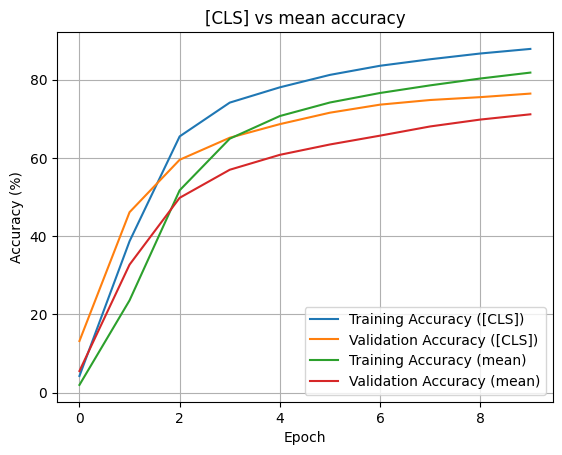

In [8]:
plt.figure()
plt.plot(training_accuracy_cls, label='Training Accuracy ([CLS])')
plt.plot(validation_accuracy_cls, label='Validation Accuracy ([CLS])')
plt.plot(training_accuracy_mean, label='Training Accuracy (mean)')
plt.plot(validation_accuracy_mean, label='Validation Accuracy (mean)')
plt.title('[CLS] vs mean accuracy')
plt.xlabel('Epoch') 
plt.ylabel('Accuracy (%)')
plt.grid()
plt.legend()

plt.show()